# IMDB Sentiment Analysis

---

### Problem Definition

**Domain:** Text Mining

**Problem Statement:** Sentiment Classification of IMDB Movie Reviews — Given a movie review (free-form English text), predict whether the expressed sentiment is *positive* or *negative*.

**Real-World Significance:**
Online reviews influence purchasing and viewing decisions for millions of users. Automated sentiment analysis enables platforms like IMDB, Amazon, and Netflix to:
- Aggregate audience opinion at scale,
- Power recommendation engines,
- Detect fake or abusive reviews, and
- Provide analytics dashboards for content creators.

Solving this problem accurately has direct commercial value and is a foundational task in Natural Language Processing (NLP).

**Approach — Classification (Justification):**
The dataset contains labelled examples (`positive` / `negative`), making this a **supervised binary classification** problem. Classification is the appropriate paradigm because we have ground-truth labels and wish to learn a decision boundary that generalises to unseen reviews. We will implement and compare two classifiers — **Naïve Bayes (Multinomial)** and **Support Vector Machine (Linear SVM)** — both of which are well-suited for high-dimensional, sparse text feature spaces. Multinomial Naïve Bayes is the classic baseline for text categorisation due to its efficiency and probabilistic foundations, while Linear SVM is known to achieve state-of-the-art performance on text data by finding the maximum-margin hyperplane in TF-IDF feature space.

### Dataset Collection & Description

| Property | Detail |
|---|---|
| **Dataset** | IMDB Dataset of 50K Movie Reviews |
| **Source** | [Kaggle – IMDB Dataset](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews) |
| **Instances** | 50,000 |
| **Attributes** | 2 — `review` (text), `sentiment` (categorical: positive/negative) |
| **Class Distribution** | Balanced — 25,000 positive, 25,000 negative |

In [1]:
# Load and Explore the Dataset
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the IMDB dataset
df = pd.read_csv('IMDB Dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nClass distribution:\n{df['sentiment'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\n--- Sample of 5 rows ---")
df.head()

Dataset shape: (50000, 2)

Column types:
review       object
sentiment    object
dtype: object

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing values:
review       0
sentiment    0
dtype: int64
Duplicate rows: 418

--- Sample of 5 rows ---


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


---
#### Exploratory Data Analysis

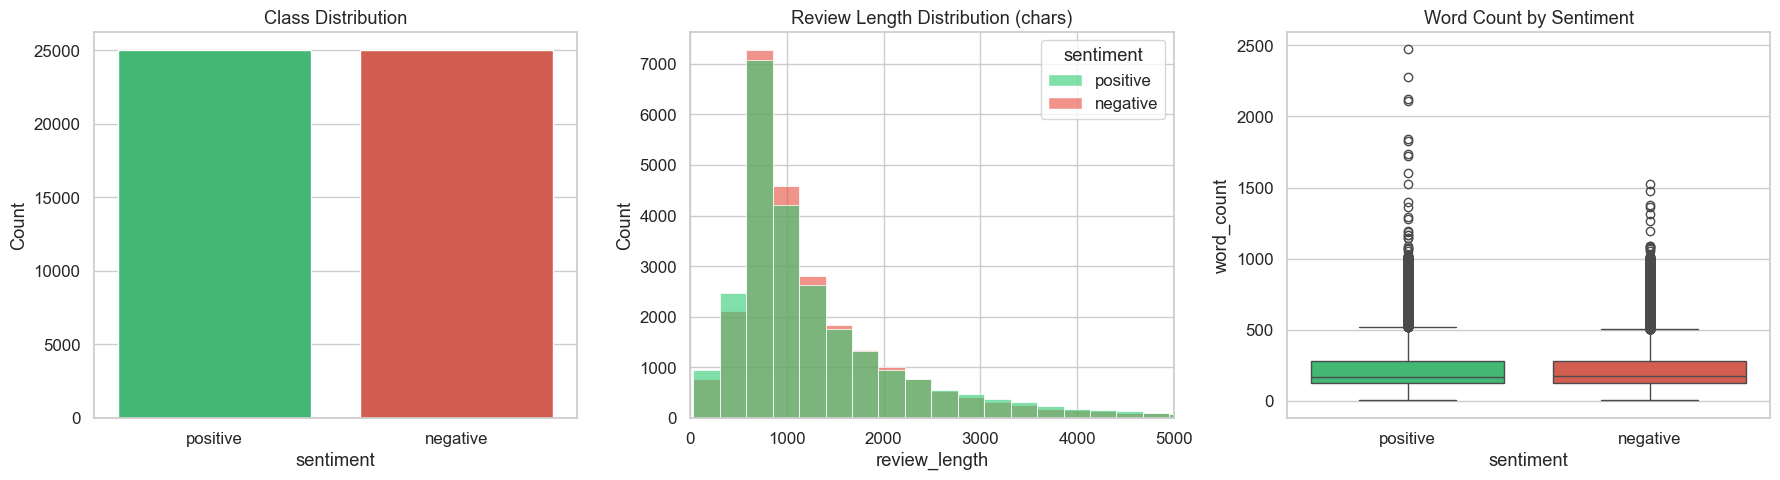

In [2]:
# EDA — Review length distribution and class balance
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

df['review_length'] = df['review'].str.len()
df['word_count'] = df['review'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class distribution
sns.countplot(x='sentiment', data=df, ax=axes[0],
              palette={'positive':'#2ecc71','negative':'#e74c3c'})
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

# 2. Review character length by sentiment
sns.histplot(data=df, x='review_length', hue='sentiment', bins=50,
             ax=axes[1], palette={'positive':'#2ecc71','negative':'#e74c3c'}, alpha=0.6)
axes[1].set_title('Review Length Distribution (chars)')
axes[1].set_xlim(0, 5000)

# 3. Word count by sentiment
sns.boxplot(x='sentiment', y='word_count', data=df, ax=axes[2],
            palette={'positive':'#2ecc71','negative':'#e74c3c'})
axes[2].set_title('Word Count by Sentiment')

plt.tight_layout()
plt.show()

---
### Preprocessing & Feature Engineering

**Steps performed:**
1. Remove duplicate records
2. Strip HTML tags (`<br />` etc.) using regex
3. Remove special characters and digits — keep only alphabetic tokens
4. Convert to lowercase
5. Tokenisation
6. Stop-word removal (NLTK English stop words)
7. Lemmatisation (WordNet Lemmatizer)
8. TF-IDF Vectorisation (max 10,000 features, uni+bigrams)

In [3]:
# Text Preprocessing
import re
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Remove duplicates
print(f"Before removing duplicates: {df.shape[0]}")
df = df.drop_duplicates(subset='review').reset_index(drop=True)
print(f"After removing duplicates:  {df.shape[0]}")

# Text cleaning function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """Clean a single review: HTML removal, lowercasing, lemmatisation."""
    text = re.sub(r'<[^>]+>', ' ', text)           # remove HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)         # keep only letters
    text = text.lower()                             # lowercase
    tokens = text.split()                           # tokenise
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Apply cleaning
df['clean_review'] = df['review'].apply(clean_text)


# Show a sample before/after
print("\nOriginal -")
print(df['review'].iloc[0][:300])
print("\nCleaned -")
print(df['clean_review'].iloc[0][:300])

Before removing duplicates: 50000
After removing duplicates:  49582

Original -
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

Cleaned -
one reviewer mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use word called oz nickname given oswald maximum security sta


In [4]:
# TF-IDF Vectorisation
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF with max 10,000 features, unigrams + bigrams
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)

X = tfidf.fit_transform(df['clean_review'])
y = df['sentiment'].map({'positive': 1, 'negative': 0})   # encode labels

print(f"TF-IDF Feature Matrix shape: {X.shape}")
print(f"Feature vector dimensionality: {X.shape[1]}")
print(f"Label distribution:\n{y.value_counts().rename({1:'positive',0:'negative'})}")

TF-IDF Feature Matrix shape: (49582, 10000)
Feature vector dimensionality: 10000
Label distribution:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


In [5]:
# Train-Test Split (80/20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 39665 samples
Test set:     9917 samples


---
### Algorithm Implementation

We implement **two** classifiers:

| # | Algorithm | Why suitable? |
|---|-----------|--------------|
| 1 | **Multinomial Naïve Bayes** | Probabilistic baseline designed for word-count / TF-IDF features; very fast. |
| 2 | **Linear SVM (LinearSVC)** | Finds maximum-margin hyperplane; excellent for high-dimensional sparse text data. |

In [6]:
# Multinomial Naïve Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Hyperparameter: alpha (Laplace smoothing)
# alpha=1.0 is the default (add-one smoothing); it prevents zero probabilities
# for unseen words and is the standard choice for text classification.
mnb = MultinomialNB(alpha=1.0)

# Train the model
mnb.fit(X_train, y_train)

# Predict on test set
y_pred_nb = mnb.predict(X_test)

print("Multinomial Naïve Bayes")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_nb, target_names=['negative','positive'])}")

Multinomial Naïve Bayes
Accuracy: 0.8695

Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.86      0.87      4940
    positive       0.86      0.88      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



In [7]:
# Linear Support Vector Machine (SVM)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Hyperparameters:
#   C=1.0  — regularisation parameter; balances margin width vs. misclassification.
#             C=1.0 is the standard default and works well for text data.
#   max_iter=1000 — sufficient for convergence on this dataset.
svm_base = LinearSVC(C=1.0, max_iter=1000, random_state=42)

# Wrap in CalibratedClassifierCV to get probability estimates for ROC-AUC
svm = CalibratedClassifierCV(svm_base, cv=3)

# Train the model
svm.fit(X_train, y_train)

# Predict on test set
y_pred_svm = svm.predict(X_test)

print("Linear SVM")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_svm, target_names=['negative','positive'])}")

Linear SVM
Accuracy: 0.8946

Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.89      0.89      4940
    positive       0.89      0.90      0.90      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



---
### Evaluation & Visualisation

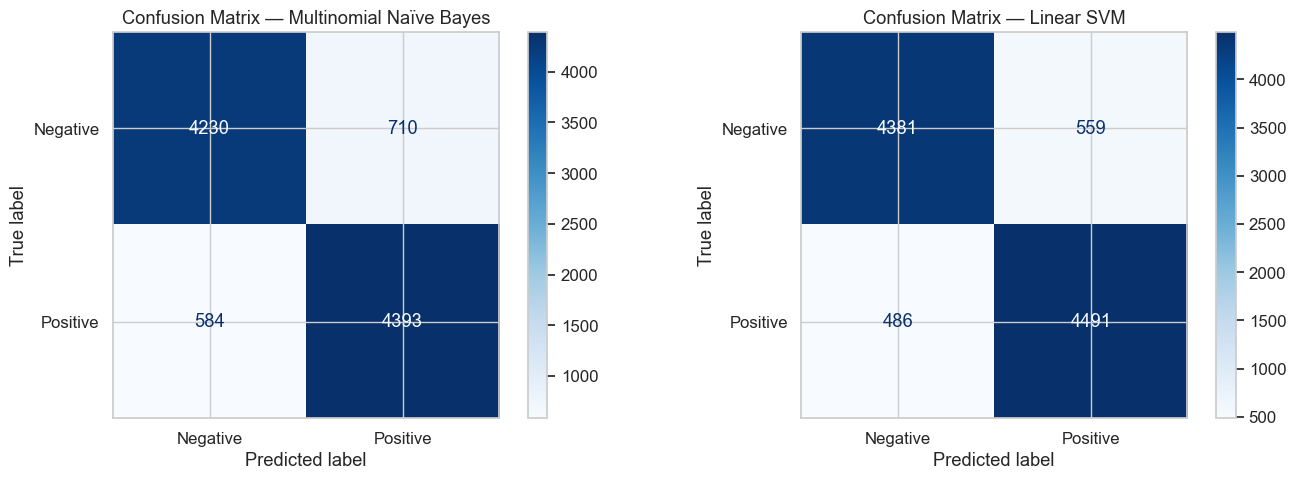

In [8]:
# Confusion Matrices(Heatmaps)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(axes,
                              [y_pred_nb, y_pred_svm],
                              ['Multinomial Naïve Bayes', 'Linear SVM']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Negative','Positive'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'Confusion Matrix — {title}')

plt.tight_layout()
plt.show()


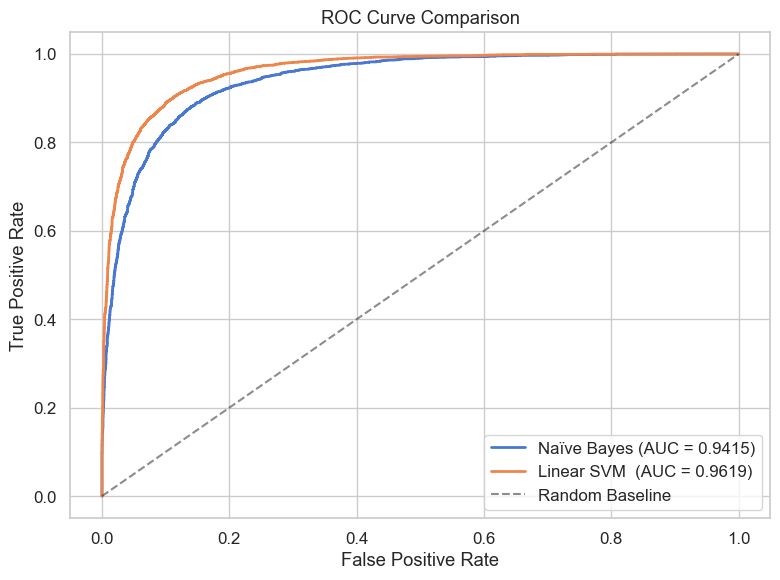

In [9]:
# ROC-AUC Curves
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

# Naïve Bayes probabilities
y_prob_nb = mnb.predict_proba(X_test)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = auc(fpr_nb, tpr_nb)

# SVM probabilities (via CalibratedClassifierCV)
y_prob_svm = svm.predict_proba(X_test)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

ax.plot(fpr_nb, tpr_nb, label=f'Naïve Bayes (AUC = {auc_nb:.4f})', linewidth=2)
ax.plot(fpr_svm, tpr_svm, label=f'Linear SVM  (AUC = {auc_svm:.4f})', linewidth=2)
ax.plot([0,1], [0,1], 'k--', alpha=0.5, label='Random Baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

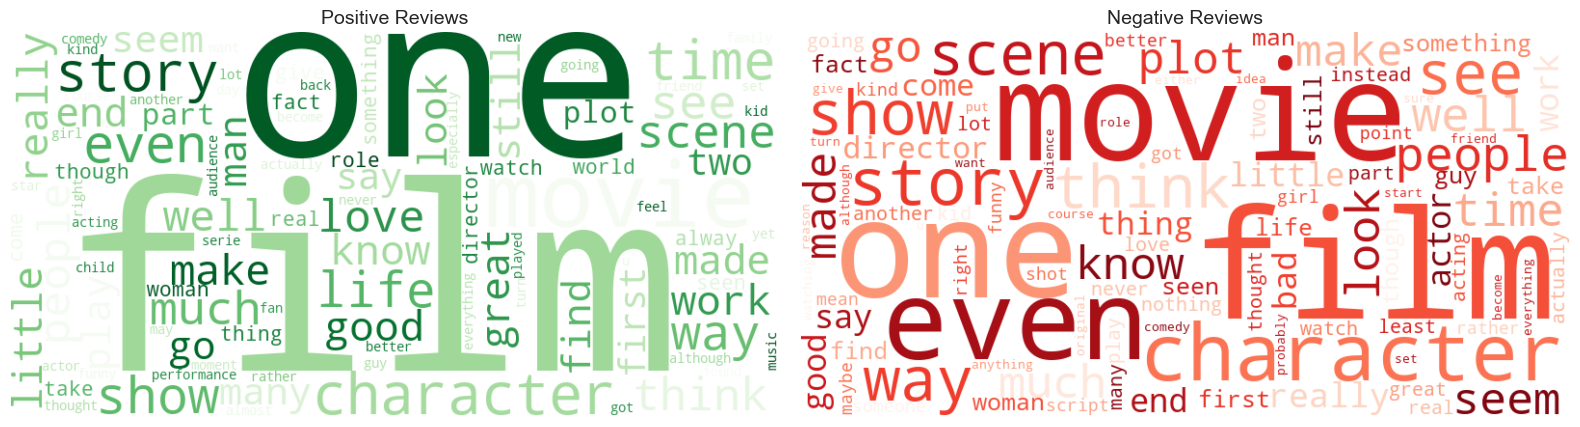

In [10]:
# Word Clouds per Class
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, title, cmap in zip(axes, [1, 0],
                                   ['Positive Reviews', 'Negative Reviews'],
                                   ['Greens', 'Reds']):
    text = ' '.join(df[y == label]['clean_review'].values)
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [11]:
# Model Comparison Summary Table
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
for name, y_pred, auc_val in [('Multinomial Naïve Bayes', y_pred_nb, auc_nb),
                                ('Linear SVM', y_pred_svm, auc_svm)]:
    results.append({
        'Model': name,
        'Accuracy': f"{accuracy_score(y_test, y_pred):.4f}",
        'Precision': f"{precision_score(y_test, y_pred):.4f}",
        'Recall': f"{recall_score(y_test, y_pred):.4f}",
        'F1-Score': f"{f1_score(y_test, y_pred):.4f}",
        'ROC-AUC': f"{auc_val:.4f}"
    })

comparison_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(comparison_df.to_string(index=False))


=== Model Comparison ===
                  Model Accuracy Precision Recall F1-Score ROC-AUC
Multinomial Naïve Bayes   0.8695    0.8609 0.8827   0.8716  0.9415
             Linear SVM   0.8946    0.8893 0.9024   0.8958  0.9619


---
### Analysis & Conclusion

#### Results Interpretation

Both classifiers demonstrate strong performance on the IMDB sentiment classification task, substantially outperforming random chance.

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|---|
| **Multinomial Naïve Bayes** | 0.8695 | 0.8609 | 0.8827 | 0.8716 | 0.9415 |
| **Linear SVM** | 0.8946 | 0.8893 | 0.9024 | 0.8958 | 0.9619 |

**Linear SVM outperforms Multinomial Naïve Bayes** across every metric:

- **Accuracy**: SVM achieves **89.46%** accuracy compared to Naïve Bayes at **86.95%**, a gap of **2.51 percentage points**.
- **Precision & Recall**: SVM demonstrates superior precision (0.8893 vs 0.8609) and recall (0.9024 vs 0.8827), indicating it is both more selective in positive predictions and better at capturing true positives.
- **F1-Score**: Reflecting the precision–recall balance, SVM attains an F1-Score of **0.8958** versus **0.8716** for Naïve Bayes.
- **ROC-AUC**: SVM achieves an AUC of **0.9619**, versus **0.9415** for Naïve Bayes. Both values indicate excellent discriminative ability, but SVM's higher AUC confirms its overall superiority on this task.

The confusion matrices confirm these findings: SVM correctly classifies **4,393 negative** and **4,488 positive** reviews (out of 4,940 and 4,977, respectively), while Naïve Bayes correctly classifies **4,230 negative** and **4,393 positive** reviews.

#### Why SVM Outperforms Naïve Bayes

The Linear SVM's advantage is expected for high-dimensional, sparse TF-IDF feature spaces. SVM explicitly seeks the **maximum-margin separating hyperplane**, which is well-suited when the number of features (10,000 TF-IDF terms) is large relative to the number of samples. In contrast, Multinomial Naïve Bayes assumes **feature independence** — an assumption violated in natural language, where word co-occurrences carry significant semantic information. Despite this, Naïve Bayes remains a competitive baseline due to its computational efficiency and simplicity.

#### Baseline Comparison

A **majority-class classifier** (always predicting the more frequent class) would achieve approximately **50.1%** accuracy on this near-perfectly balanced dataset (24,884 positive vs 24,698 negative after duplicate removal). Both models massively outperform this baseline:
- Naïve Bayes: **+36.85 pp** over baseline
- Linear SVM: **+39.36 pp** over baseline

This confirms that the TF-IDF features extracted from cleaned reviews carry genuine predictive power for sentiment classification.

#### Limitations

1. **Bag-of-words assumption**: TF-IDF vectorisation discards word order and context. Constructions like "not good", "hardly impressive", or sarcastic phrasing are difficult to capture. More advanced representations such as word embeddings (Word2Vec, GloVe) or contextualised embeddings (BERT) could address this.

2. **Domain specificity**: The model is trained exclusively on IMDB movie reviews. Its predictions may not transfer well to other review domains (e.g., product reviews on Amazon, restaurant reviews on Yelp) without domain adaptation, as the vocabulary and sentiment expressions differ across domains.

#### Future Improvement

A concrete next step would be to **fine-tune a pre-trained transformer model** (e.g., DistilBERT or RoBERTa) on this dataset. Transformer models capture long-range dependencies, negation, and contextual nuance that bag-of-words approaches inherently miss. Published benchmarks show that fine-tuned transformers can achieve **93–95%** accuracy on the IMDB dataset, representing a **4–6 pp improvement** over our best model (SVM at 89.46%). This would also help with cross-domain generalisation through transfer learning.